# 0. Load imports 

In [1]:
## imports
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

## print multiple things from same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## load data on 2020 crimes in DC
df = dc_crim_2020 = pd.read_csv("https://opendata.arcgis.com/datasets/f516e0dd7b614b088ad781b0c4002331_2.csv")

# 1. Questions: list comprehension

- In class example, why did we need the "courses" at the beginning of the list iteration
- How did the join syntax work in the example where we paste together offenses from same ward

In [2]:
## toy example

### pool of courses
all_courses = ["QSS20", "QSS17", "GOV10", "GOV4", "CSC1"]


## 1.1 Application 1: filtering to a smaller list

When we might use: have a lot of columns in a dataframe; want to filter to a smaller set using some pattern

In [3]:
### pull out ones that contain GOV in the string
gov_c = [course for course in all_courses if "GOV" in course]
gov_c # result

['GOV10', 'GOV4']

In [4]:
### showing that the "course" is just a placeholder/
### arbitrary interator
gov_c_alt = [x for x in all_courses if "GOV" in x]

gov_c == gov_c_alt

True

## 1.2 Application two: keep all objects in the list but do some transformation

In [5]:
all_courses

## strip the numbers from the course names
courses_prefix = [x[:3] for x in all_courses]
courses_prefix # could then find unique elements


['QSS20', 'QSS17', 'GOV10', 'GOV4', 'CSC1']

['QSS', 'QSS', 'GOV', 'GOV', 'CSC']

In [6]:
# Join all together example
" #:(# ".join(courses_prefix)

'QSS #:(# QSS #:(# GOV #:(# GOV #:(# CSC'

#### Your turn: Using original list, add "dartmouth_" prefix to the course name

In [14]:
all_courses

courses_addprefix = ["dartmouth_" + x for x in all_courses]
courses_addprefix

['QSS20', 'QSS17', 'GOV10', 'GOV4', 'CSC1']

['dartmouth_QSS20',
 'dartmouth_QSS17',
 'dartmouth_GOV10',
 'dartmouth_GOV4',
 'dartmouth_CSC1']

## 1.3 Subsetting columns

Use list comprehension to filter to columns with id in the string. Then, create a new dataframe called df1 that contains only column heads with "id"

In [16]:
id_cols = [col for col in df.columns if "ID" in col]
id_cols

## Then, filter the data
df[id_cols].head()

['BID', 'OBJECTID', 'OCTO_RECORD_ID']

,BID,OBJECTID,OCTO_RECORD_ID
0,DUPONT CIRCLE,976657932,NaN
1,NaN,976657941,NaN
2,NaN,976657942,NaN
3,NaN,976657945,NaN
4,NaN,976657959,NaN


## 1.4 Comprehension for numbers

Here we compare two ways of creating a list of even numbers.

In [17]:
num_list = np.arange(10000)
num_list

array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(10000,))

In [19]:
%%time
even_nums = [i for i in num_list if (i % 2) == 0]

CPU times: total: 15.6 ms
Wall time: 3.23 ms


In [18]:
%%time
num_list[~(num_list % 2).astype(bool)]

CPU times: total: 0 ns
Wall time: 339 μs


array([   0,    2,    4, ..., 9994, 9996, 9998], shape=(5000,))

In [20]:
num_list[ ~(num_list % 2).astype(bool) ]

array([   0,    2,    4, ..., 9994, 9996, 9998], shape=(5000,))

#### Your turn: Extract all numbers in num_list that end in 7

In [32]:
sevens = [i for i in num_list if (i % 10) == 7]

#### Your turn: Divide each number  in num_list by 2

In [30]:
twos = [x / 2 for x in num_list]

# 2. Questions: lambda functions

Two questions:

- General syntax (see here for a reference: https://www.w3schools.com/python/python_lambda.asp 
- How they work in the context of aggregations

How is a lambda function different from a "normal" user-defined function (that has the syntax def func_name(arg): etc?

- Operates similarly to normal user-defined functions in that it can take any # of arguments
- Operates differently in that it's an "anonymous" function or a function that we don't explicitly name/save in memory

## 2.1 General syntax for lambda functions

In [33]:
### two pools of courses
socsci = ["QSS20", "QSS17", "GOV10"]
natsci = ["BIO2", "PHYS3"]


## generalize some of the steps
## above into a two-arg function
## that takes the course prefix
## and a list of all courses
def filter_courses(prefix, all_courses):
    rel_courses = [c for c in all_courses if prefix in c]
    return(rel_courses)

### a few applications 
filter_courses(prefix = "QSS", all_courses = socsci)
filter_courses(prefix = "QSS", all_courses = natsci)
filter_courses(prefix = "BIO", all_courses = natsci)

['QSS20', 'QSS17']

[]

['BIO2']

In [34]:
## what's the lambda function version of this
filter_courses_v2 = lambda prefix, all_courses: [c for c in all_courses if prefix in c]
filter_courses_v2(prefix = "BIO", all_courses = natsci)


['BIO2']

## 2.2 using alongside agg

In [35]:
## use lambda to find modal block in a ward- multiple ways

### way 1: subsetting agg syntex
df.groupby("WARD")["BLOCK"].agg(lambda x: x.mode())

### way 2: dictionary agg syntax
df.groupby("WARD").agg({"BLOCK": lambda x: x.mode()})


WARD
1                  3100 - 3299 BLOCK OF 14TH STREET NW
2    [1100 - 1199 BLOCK OF NEW YORK AVENUE NW, 1300...
3             5300 - 5399 BLOCK OF WISCONSIN AVENUE NW
4                100  - 199 BLOCK OF CARROLL STREET NW
5            900 - 999 BLOCK OF RHODE ISLAND AVENUE NE
6                       600 - 699 BLOCK OF H STREET NE
7                934 - 1099 BLOCK OF EASTERN AVENUE NE
8               2300 - 2399 BLOCK OF GOOD HOPE ROAD SE
Name: BLOCK, dtype: object

,BLOCK
WARD,
1,3100 - 3299 BLOCK OF 14TH STREET NW
2,"[1100 - 1199 BLOCK OF NEW YORK AVENUE NW, 1300..."
3,5300 - 5399 BLOCK OF WISCONSIN AVENUE NW
4,100 - 199 BLOCK OF CARROLL STREET NW
5,900 - 999 BLOCK OF RHODE ISLAND AVENUE NE
6,600 - 699 BLOCK OF H STREET NE
7,934 - 1099 BLOCK OF EASTERN AVENUE NE
8,2300 - 2399 BLOCK OF GOOD HOPE ROAD SE


#### Your turn: Group by WARD and get the mean and standard deviation (std) of X and Y

In [36]:
df.groupby("WARD")[["X", "Y"]].agg(["mean", "std"])

X                           Y             
               mean          std           mean          std
WARD                                                        
1     397289.867555   624.307287  139648.610621   712.362815
2     396621.067712  1223.488923  137564.793599   595.099248
3     393470.489099  1162.323901  141520.418724  1541.617708
4     397841.637555  1023.793670  143307.153700  1545.603726
5     400915.575468  1297.551690  139152.417438  1416.967174
6     399898.301927   980.505436  136139.856333  1112.374544
7     404563.412110  1626.707129  135648.075402  1388.268228
8     400956.107708  1110.298221  131412.540814  1751.194450

### Random sampling and distance measures

In [37]:
random_uniform = np.random.rand(5)  # 5 random numbers between 0 and 1
print("Random numbers from uniform distribution:", random_uniform)

random_normal = np.random.randn(5)  # 5 random numbers from a standard normal distribution
print("Random numbers from normal distribution:", random_normal)

Random numbers from uniform distribution: [0.02577949 0.24582281 0.5263699  0.39557498 0.02185357]
Random numbers from normal distribution: [ 1.33811623  0.78270306 -0.7409561   1.35522672  1.0948223 ]


<Axes: ylabel='Density'>

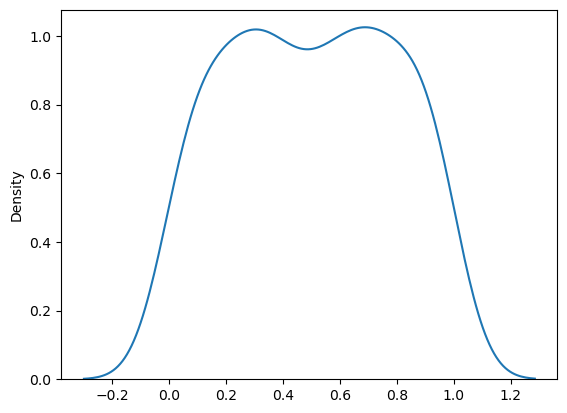

In [46]:
N = 200

sns.kdeplot(np.random.rand(N))

<Axes: ylabel='Density'>

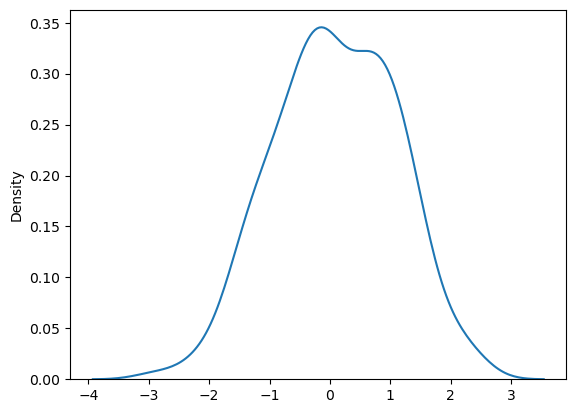

In [48]:
sns.kdeplot(np.random.randn(N))